In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from WBUtiles.WBClean import clean_wb_wide
from WBUtiles.WBSummary import summary_wb, plot_missing_heatmap
from WBUtiles.WBLatex import make_lookup_latex, make_summary_latex

sns.set_theme(
    style="whitegrid",     # clean academic look
    context="paper",       # scales text for papers
    font_scale=1.1
)

In [24]:
# import data
lic_demo = pd.read_csv('../../data/LIC_Demographic/LIC_demo.csv')
zambia_demo = pd.read_csv('../../data/Zambia_Demographic/demo.csv')

lic_pop = pd.read_csv('../../data/LIC_Population/LIC_pop.csv')
zambia_pop = pd.read_csv('../../data/Zambia_Population/pop.csv')

In [25]:
lic_clean, lic_lookup = clean_wb_wide(lic_demo)
zambia_clean, zambia_lookup = clean_wb_wide(zambia_demo)

lic_pop_clean, lic_pop_lookup = clean_wb_wide(lic_pop)
zambia_pop_clean, zambia_pop_lookup = clean_wb_wide(zambia_pop)

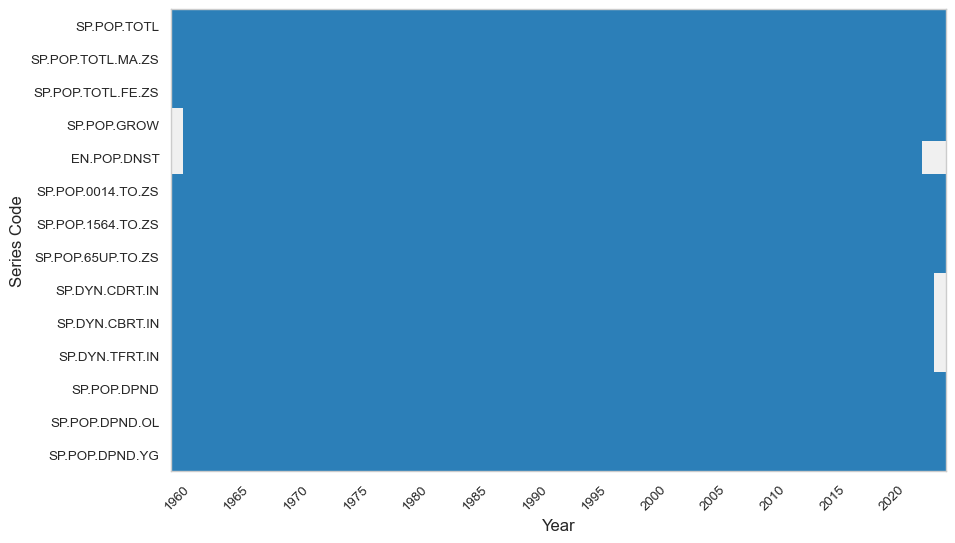

In [4]:
# plot missing data heatmap
availability, fig, ax = plot_missing_heatmap(
    lic_clean,
    lookup=lic_lookup,
)

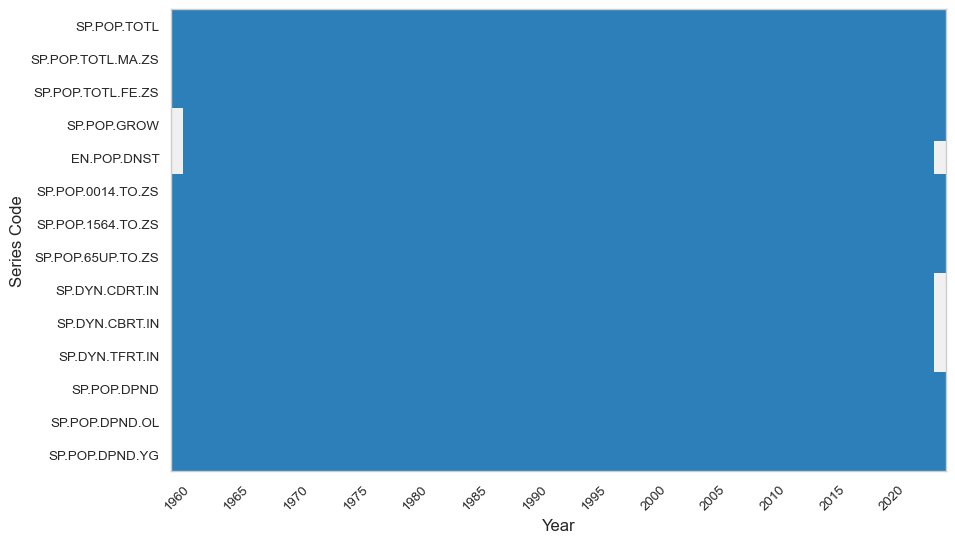

In [5]:
availability, fig, ax = plot_missing_heatmap(
    zambia_clean,
    lookup=zambia_lookup,
)

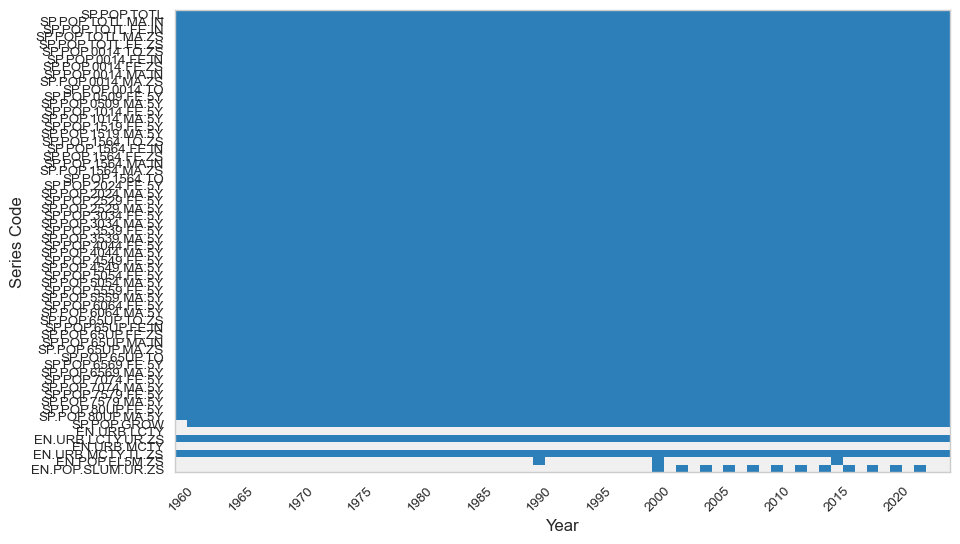

In [26]:
availability, fig, ax = plot_missing_heatmap(
    lic_pop_clean,
    lookup=lic_pop_lookup,
)

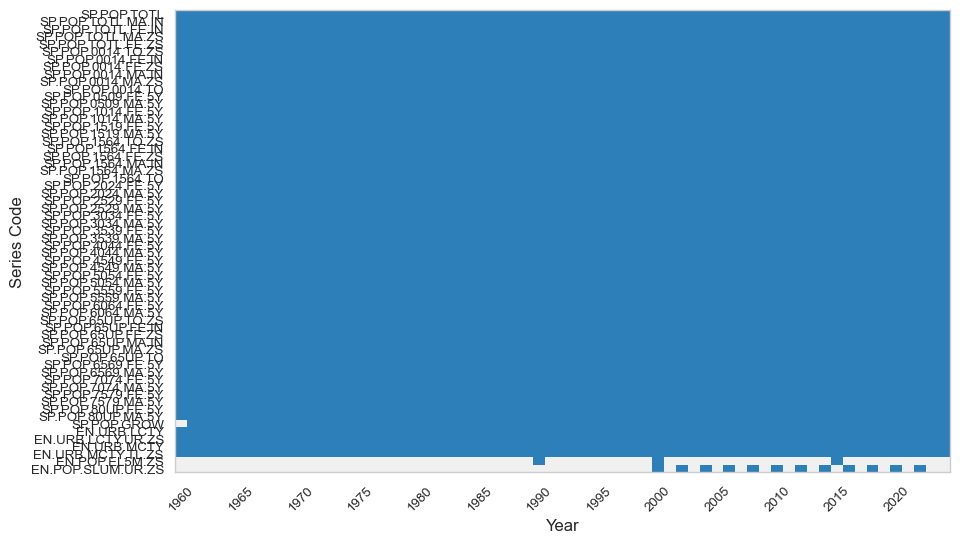

In [27]:
availability, fig, ax = plot_missing_heatmap(
    zambia_pop_clean,
    lookup=zambia_pop_lookup,
)

# Population

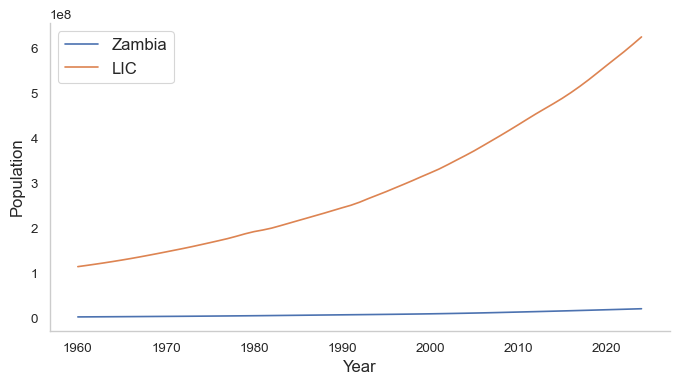

In [10]:
# Total population
df_lic = lic_clean.set_index('Year')
df_zambia = zambia_clean.set_index('Year')
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df_zambia.index, df_zambia['SP.POP.TOTL'], label='Zambia')
ax.plot(df_lic.index, df_lic['SP.POP.TOTL'], label='LIC')

# ax.set_title('Total population')
ax.set_ylabel('Population', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.legend(fontsize=12)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/LIC/demographic/pop_total_LIC_zambia.pdf",
    format="pdf",
    bbox_inches="tight"
)

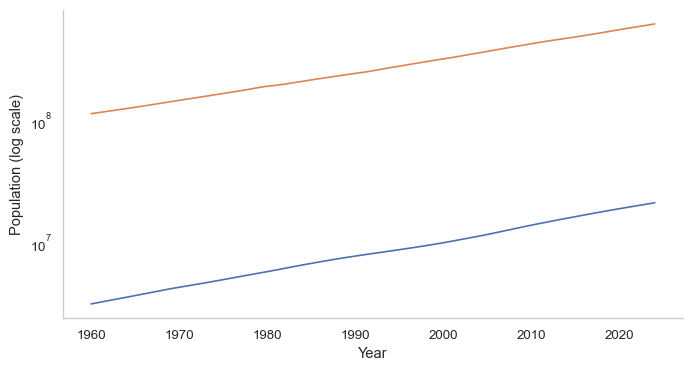

In [11]:
# Total population log
df_lic = lic_clean.set_index('Year')
df_zambia = zambia_clean.set_index('Year')
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df_zambia.index, df_zambia['SP.POP.TOTL'])
ax.plot(df_lic.index, df_lic['SP.POP.TOTL'])
ax.set_yscale('log')

# ax.set_title('Total population (log scale)')
ax.set_ylabel('Population (log scale)')
ax.set_xlabel('Year')

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/LIC/demographic/pop_total_log_LIC_zambia.pdf",
    format="pdf",
    bbox_inches="tight"
)

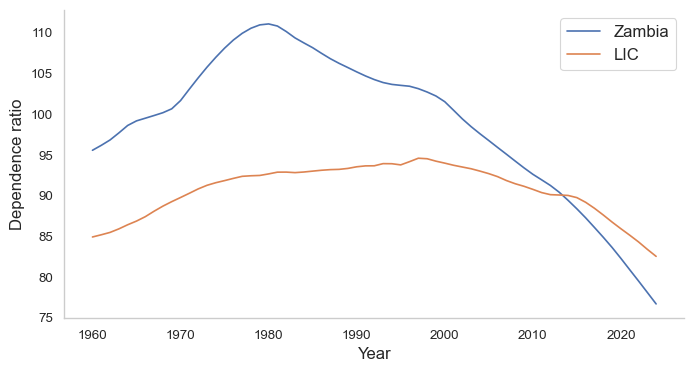

In [12]:
# Dependence ratio
df_lic = lic_clean.set_index('Year')
df_zambia = zambia_clean.set_index('Year')
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df_zambia.index, df_zambia['SP.POP.DPND'], label='Zambia')
ax.plot(df_lic.index, df_lic['SP.POP.DPND'], label='LIC')

# ax.set_title('Dependence ratio')
ax.set_ylabel('Dependence ratio', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.legend(fontsize=12)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/LIC/demographic/dependence_ratio_LIC_zambia.pdf",
    format="pdf",
    bbox_inches="tight"
)

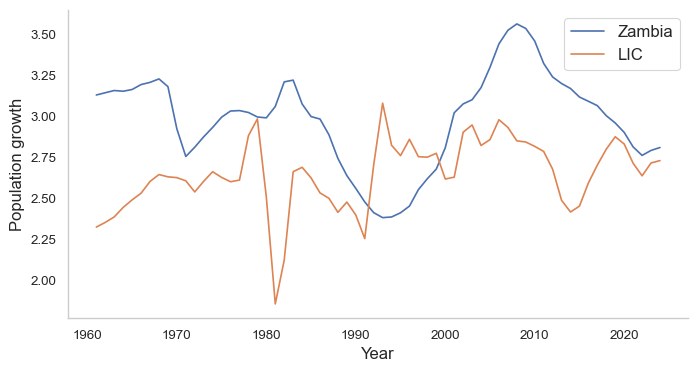

In [13]:
# Population growth
df_lic = lic_clean.set_index('Year')
df_zambia = zambia_clean.set_index('Year')
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df_zambia.index, df_zambia['SP.POP.GROW'], label='Zambia')
ax.plot(df_lic.index, df_lic['SP.POP.GROW'], label='LIC')

# ax.set_title('Population growth')
ax.set_ylabel('Population growth', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.legend(fontsize=12)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/LIC/demographic/pop_growth_LIC_zambia.pdf",
    format="pdf",
    bbox_inches="tight"
)

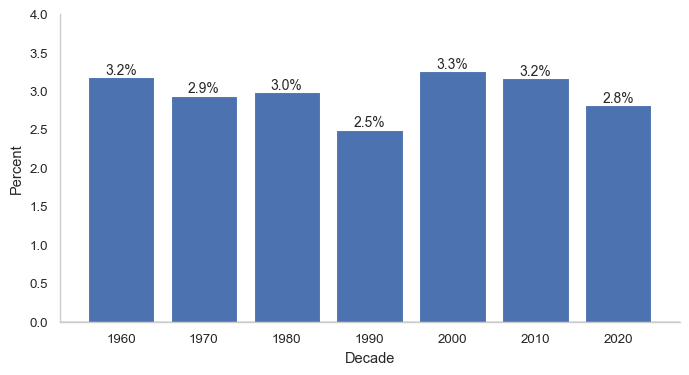

In [17]:
# Population growth decade

# keep annual growth
df_growth = zambia_clean[['Year', 'SP.POP.GROW']].dropna()

# define decade
df_growth['decade'] = (df_growth['Year'] // 10) * 10

# compute average annual growth per decade
decadal_avg = (
    df_growth.groupby('decade')['SP.POP.GROW']
    .mean()
    .reset_index()
)

# keep only full decades if you prefer (optional)
# decadal_avg = decadal_avg[decadal_avg['decade'] >= 1980]

fig, ax = plt.subplots(figsize=(8,4))

bars = ax.bar(
    decadal_avg['decade'].astype(str),
    decadal_avg['SP.POP.GROW']
)

ax.axhline(0, linewidth=1)
# ax.set_title('Average annual population growth by decade')
ax.set_xlabel('Decade')
ax.set_ylabel('Percent')

ax.set_ylim(0, 4)

# Add percentage labels above bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Clean style (journal ready)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/LIC/demographic/pop_growth_decade_zambia.pdf",
    format="pdf",
    bbox_inches="tight"
)

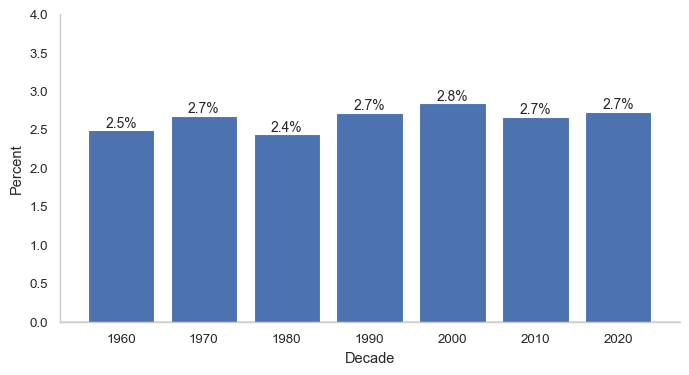

In [18]:
# Population growth decade

# keep annual growth
df_growth = lic_clean[['Year', 'SP.POP.GROW']].dropna()

# define decade
df_growth['decade'] = (df_growth['Year'] // 10) * 10

# compute average annual growth per decade
decadal_avg = (
    df_growth.groupby('decade')['SP.POP.GROW']
    .mean()
    .reset_index()
)

# keep only full decades if you prefer (optional)
# decadal_avg = decadal_avg[decadal_avg['decade'] >= 1980]

fig, ax = plt.subplots(figsize=(8,4))

bars = ax.bar(
    decadal_avg['decade'].astype(str),
    decadal_avg['SP.POP.GROW']
)

ax.axhline(0, linewidth=1)
# ax.set_title('Average annual population growth by decade')
ax.set_xlabel('Decade')
ax.set_ylabel('Percent')

ax.set_ylim(0, 4)

# Add percentage labels above bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Clean style (journal ready)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/LIC/demographic/pop_growth_decade_lic.pdf",
    format="pdf",
    bbox_inches="tight"
)

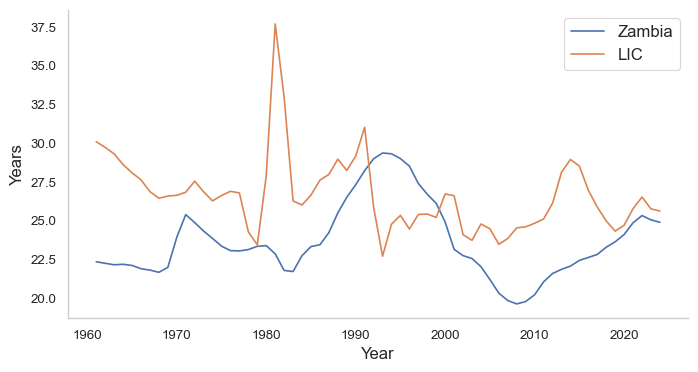

In [22]:
# Population Doubling Time
df_lic = lic_clean.set_index('Year')
df_zambia = zambia_clean.set_index('Year')

# Avoid division by zero or negative growth
df_zambia['doubling_time'] = 70 / df_zambia['SP.POP.GROW']
df_lic['doubling_time'] = 70 / df_lic['SP.POP.GROW']

fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df_zambia.index, df_zambia['doubling_time'], label='Zambia')
ax.plot(df_lic.index, df_lic['doubling_time'], label='LIC')

# ax.set_title('Population doubling time')
ax.set_ylabel('Years', fontsize=12)
ax.set_xlabel('Year', fontsize=12)

ax.legend(fontsize=12)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/LIC/demographic/pop_double_time_LIC_zambia.pdf",
    format="pdf",
    bbox_inches="tight"
)

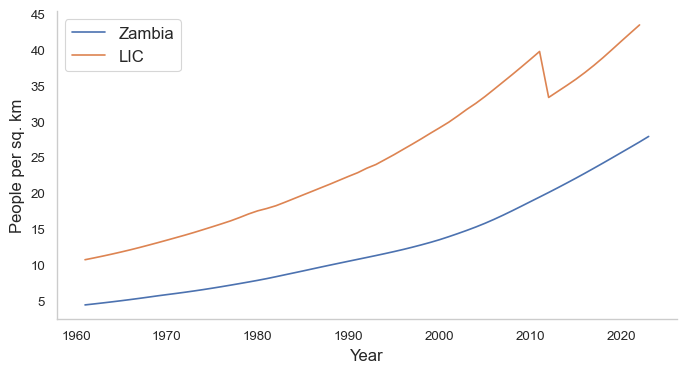

In [23]:
# Population Density
df_lic = lic_clean.set_index('Year')
df_zambia = zambia_clean.set_index('Year')
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df_zambia.index, df_zambia['EN.POP.DNST'], label='Zambia')
ax.plot(df_lic.index, df_lic['EN.POP.DNST'], label='LIC')

# ax.set_title('Population density')
ax.set_ylabel('People per sq. km', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.legend(fontsize=12)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/LIC/demographic/pop_density_LIC_zambia.pdf",
    format="pdf",
    bbox_inches="tight"
)

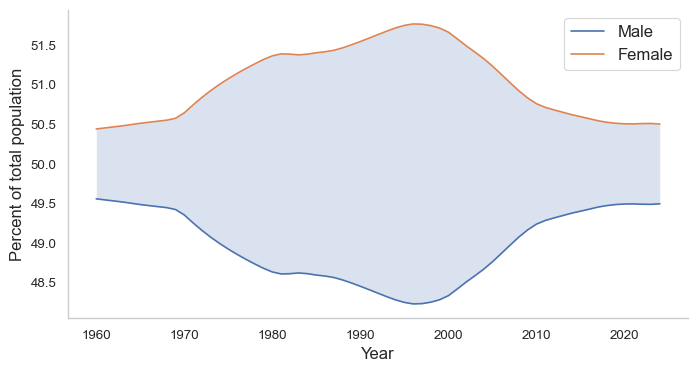

In [57]:
# Sex Composition of the population Zambia
fig, ax = plt.subplots(figsize=(8,4))

df = zambia_pop_clean.set_index('Year')

ax.plot(df.index, 100 - df['SP.POP.TOTL.FE.ZS'], label='Male')
ax.plot(df.index, df['SP.POP.TOTL.FE.ZS'], label='Female')

# ax.set_title('Sex composition of the population')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Percent of total population', fontsize=12)
ax.legend(fontsize=12)

# fill between lines
ax.fill_between(df.index, 100 - df['SP.POP.TOTL.FE.ZS'], df['SP.POP.TOTL.FE.ZS'], alpha=0.2)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/LIC/demographic/pop_sex_zambia.pdf",
    format="pdf",
    bbox_inches="tight"
)

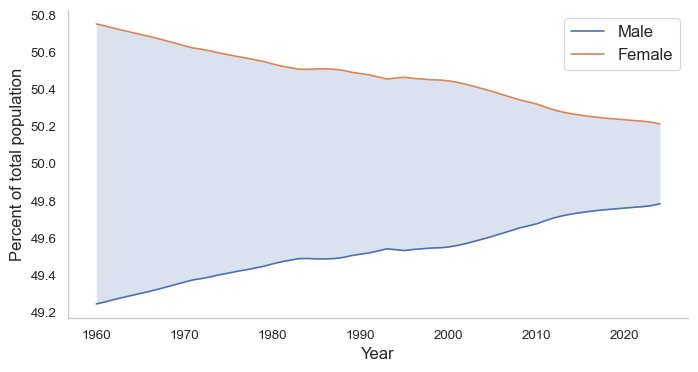

In [58]:
# Sex Composition of the population LIC
fig, ax = plt.subplots(figsize=(8,4))

df = lic_pop_clean.set_index('Year')

ax.plot(df.index, 100 - df['SP.POP.TOTL.FE.ZS'], label='Male')
ax.plot(df.index, df['SP.POP.TOTL.FE.ZS'], label='Female')

# ax.set_title('Sex composition of the population')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Percent of total population', fontsize=12)
ax.legend(fontsize=12)

# fill between lines
ax.fill_between(df.index, 100 - df['SP.POP.TOTL.FE.ZS'], df['SP.POP.TOTL.FE.ZS'], alpha=0.2)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/LIC/demographic/pop_sex_lic.pdf",
    format="pdf",
    bbox_inches="tight"
)

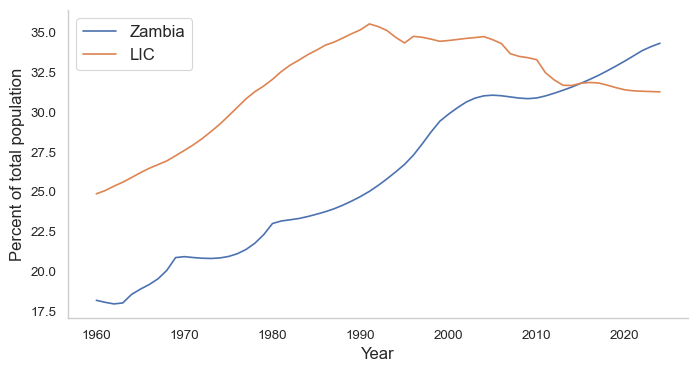

In [48]:
# Population in the largest city (% of urban population)
df_lic = lic_pop_clean.set_index('Year')
df_zambia = zambia_pop_clean.set_index('Year')
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df_zambia.index, df_zambia['EN.URB.LCTY.UR.ZS'], label='Zambia')
ax.plot(df_lic.index, df_lic['EN.URB.LCTY.UR.ZS'], label='LIC')

# ax.set_title('Population in the largest city (% of urban population)')
ax.set_ylabel('Percent of total population', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.legend(fontsize=12)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/LIC/demographic/urban_pop_LIC_zambia.pdf",
    format="pdf",
    bbox_inches="tight"
)

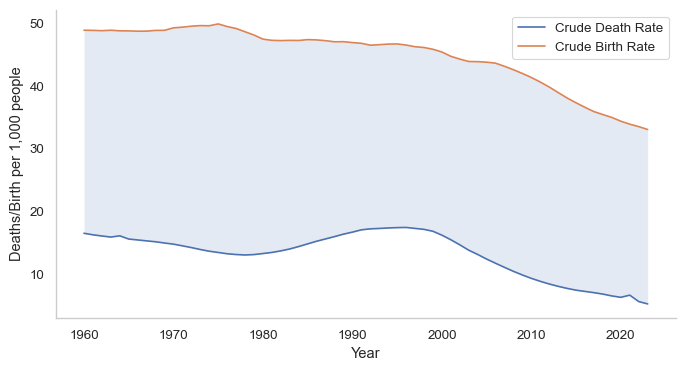

In [50]:
# Crude Death/Birth Rate
df = zambia_clean.set_index('Year')

fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df.index, df['SP.DYN.CDRT.IN'])
ax.plot(df.index, df['SP.DYN.CBRT.IN'])
# ax.set_title('Crude Death/Birth Rate')
ax.set_ylabel('Deaths/Birth per 1,000 people')
ax.set_xlabel('Year')
ax.legend(['Crude Death Rate', 'Crude Birth Rate'])

ax.fill_between(
    df.index,
    df['SP.DYN.CDRT.IN'],   # lower line
    df['SP.DYN.CBRT.IN'],   # upper line
    alpha=0.15
)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/LIC/demographic/crude_death_birth_zambia.pdf",
    format="pdf",
    bbox_inches="tight"
)

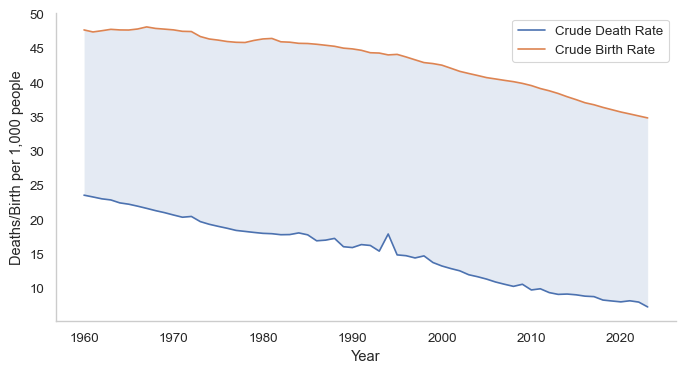

In [51]:
# Crude Death/Birth Rate
df = lic_clean.set_index('Year')

fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df.index, df['SP.DYN.CDRT.IN'])
ax.plot(df.index, df['SP.DYN.CBRT.IN'])
# ax.set_title('Crude Death/Birth Rate')
ax.set_ylabel('Deaths/Birth per 1,000 people', fontsize=12)
ax.set_xlabel('Year')
ax.legend(['Crude Death Rate', 'Crude Birth Rate'])

ax.fill_between(
    df.index,
    df['SP.DYN.CDRT.IN'],   # lower line
    df['SP.DYN.CBRT.IN'],   # upper line
    alpha=0.15
)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/LIC/demographic/crude_death_birth_lic.pdf",
    format="pdf",
    bbox_inches="tight"
)

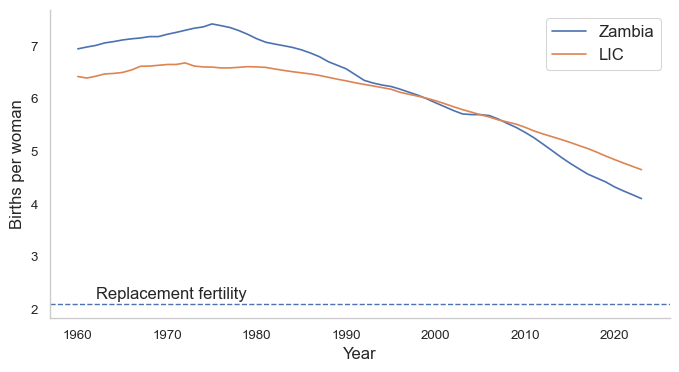

In [56]:
# Total Fertility Rate
df_zambia = zambia_clean.set_index('Year')
df_lic = lic_clean.set_index('Year')
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df.index, df_zambia['SP.DYN.TFRT.IN'], label='Zambia')
ax.plot(df.index, df_lic['SP.DYN.TFRT.IN'], label='LIC')

# ax.set_title('Total fertility rate')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Births per woman', fontsize=12)
ax.legend(fontsize=12)

ax.axhline(2.1, linestyle='--', linewidth=1)
ax.text(1962, 2.2, 'Replacement fertility', fontsize=12)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/LIC/demographic/total_fertility_LIC_zambia.pdf",
    format="pdf",
    bbox_inches="tight"
)